Here we import all libraries required for the analysis of opc files. Each library has its own characteristics and functions. Moreover, these are very useful for a wide spectrum of data analysis, so take notes especially if this is your first approach to pyhton!

For any problems you can contact me at my email: andrea.faggi3@unibo.it

To install a package you can try to open the prompt of your compiler (such as miniconda, etc.) and type:

    pip install *package name*

In [2]:
import numpy as np                     # This library contains a lot of numerical functions and it is useful for calculations
import os                              # This library allows to set the working directory
import pandas as pd                    # This library allows the data analysis and manipulation of datasets in different formats

import matplotlib as mtp               # This library contains a lot of functions for plotting
import matplotlib.dates as md
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy import stats                # This library allows statistical analysis and it is used here to make data interpolations
from scipy.stats import t              # and to compute statistical distributions
import statsmodels.api as sm

Note that you can add comments in your python code by typing # and write your comment on the same line.
There is also another way to add comments and here you are:

In [3]:
'''
You can also add a comment on different lines: write three apostrophe to start and other three apostrophe to end the comment.
Just like this!
'''

'\nYou can also add a comment on different lines: write three apostrophe to start and other three apostrophe to end the comment.\nJust like this!\n'

The following is a function to plot your data in a similar way OpenAir scatterPlot does on R. Do not change this function in the beginning, but if you want to change some colors or other things do it at your risk. Anyway, feel free to ask.

In [4]:
def scatterPlot (dataset1, dataset2, var1_name, var2_name, x_axis_name, y_axis_name, saving_name, title1, title2):
    # figure and plot
    fig,axes=plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(10,5))
    ax = axes.flatten()[0]
    # linear regression 
    result = stats.linregress(dataset1[var1_name], dataset1[var2_name])

    # 95% confidence interval computation
    X = dataset1[var1_name]
    Y = dataset1[var2_name]
    X = sm.add_constant(X)
    model = sm.OLS(Y,X).fit()
    xseq = pd.Series(np.linspace(np.min(dataset1[var1_name]), np.max(dataset1[var1_name]), len(dataset1[var1_name])))
    xseq_with_const = sm.add_constant(xseq)
    predictions = model.get_prediction(xseq_with_const)
    predicted_values = predictions.predicted_mean
    ci = predictions.conf_int(alpha=0.05)  # ci% = 1 - alpha

    # background colors and grid 
    #ax.set_facecolor("gainsboro")
    ax.grid(color = "#d0d0d0")

    # scatterplot of dataset
    ax.scatter(dataset1[var1_name], dataset1[var2_name], edgecolors='red', linewidth=0.7, alpha=0.5, facecolors='none', zorder=5)

    # linear regression plot and confidence intervals
    ax.plot(xseq, predicted_values, 'k', zorder=2)
    ax.fill_between(xseq, ci[:,0], ci[:,1], color='g', alpha=0.2)

    # set limits to x and y axes (optional) 
    #ax.set_xlim(left=0)
    #ax.set_ylim(bottom=0)

    # add name to x and y axes
    ax.set_xlabel(x_axis_name)
    ax.set_ylabel(y_axis_name)
    ax.set_title(title1)

    # add results of linear regression (slope, intercept, r^2)
    ax.annotate(var1_name + ' = '+str(np.round(result.slope, 2))+' * ['+ var2_name +'] + '+str(np.round(result.intercept,2))+'; R$^2$ = '+str(np.round(result.rvalue**2,2)), 
                   xy=(0,0), xytext=(0.10,0.94),
                   ha='left', va='center', fontsize=12,
                   xycoords='axes fraction')
####################################################################################
    # linear regression 
    ax = axes.flatten()[1]
    result = stats.linregress(dataset2[var1_name], dataset2[var2_name])

    # 95% confidence interval computation
    X = dataset2[var1_name]
    Y = dataset2[var2_name]
    X = sm.add_constant(X)
    model = sm.OLS(Y,X).fit()
    xseq = pd.Series(np.linspace(np.min(dataset2[var1_name]), np.max(dataset2[var1_name]), len(dataset2[var1_name])))
    xseq_with_const = sm.add_constant(xseq)
    predictions = model.get_prediction(xseq_with_const)
    predicted_values = predictions.predicted_mean
    ci = predictions.conf_int(alpha=0.05)  # ci% = 1 - alpha

    # background colors and grid 
    #ax.set_facecolor("gainsboro")
    ax.grid(color = "#d0d0d0")

    # scatterplot of dataset
    ax.scatter(dataset2[var1_name], dataset2[var2_name], edgecolors='red', linewidth=0.7, alpha=0.5, facecolors='none', zorder=5)

    # linear regression plot and confidence intervals
    ax.plot(xseq, predicted_values, 'k', zorder=2)
    ax.fill_between(xseq, ci[:,0], ci[:,1], color='g', alpha=0.2)

    # set limits to x and y axes (optional) 
    #ax.set_xlim(left=0)
    #ax.set_ylim(bottom=0)

    # add name to x and y axes
    ax.set_xlabel(x_axis_name)
    ax.set_ylabel(y_axis_name)
    ax.set_title(title2)

    # add results of linear regression (slope, intercept, r^2)
    ax.annotate(var1_name + ' = '+str(np.round(result.slope, 2))+' * ['+ var2_name +'] + '+str(np.round(result.intercept,2))+'; R$^2$ = '+str(np.round(result.rvalue**2,2)), 
                   xy=(0,0), xytext=(0.10,0.94),
                   ha='left', va='center', fontsize=12,
                   xycoords='axes fraction')

    # saving plot and closing figure (optional)
    fig.savefig(saving_name, bbox_inches='tight')
    #plt.close(fig)


In [5]:
def timePlot(dataset1, dataset2, time_name, var1_name, label1, var2_name, label2, y_axis_name, saving_name, title1, title2, hline):
    
    # figure and plot
    fig,axes=plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(10,8))
    ax = axes[0]
    # background colors and grid 
    #ax.set_facecolor("gainsboro")
    ax.grid(color = "#d0d0d0")

    # add timeseries of dataset fields in the plot
    ax.plot(dataset1[time_name],dataset1[var1_name], 'r', alpha=0.8, zorder=5, label=label1)
    ax.plot(dataset1[time_name],dataset1[var2_name], 'grey', linestyle='--', zorder=5, label=label2)
    if hline != 0:
        ax.axhline(y=hline, color='b', linestyle='-')
        ax.text(dataset1[time_name][1], hline, 'ARPAE: '+str(hline), fontsize=12, va='center', ha='center', color='b', backgroundcolor='w', zorder=6)
    #media PM10 e PM2.5
    pm10_meas_avg = dataset1[var1_name].mean()
    ax.axhline(y=pm10_meas_avg, color='r', linestyle='-')
    ax.text(dataset1[time_name][dataset1.shape[0]-2], pm10_meas_avg, 'MEAS: {:.2f}'.format(pm10_meas_avg), fontsize=12, va='center', ha='center', color='r', backgroundcolor='w', zorder=6)
    pm10_calc_avg = dataset1[var2_name].mean()
    ax.axhline(y=pm10_calc_avg, color='grey', linestyle='--')
    ax.text(dataset1[time_name][dataset1.shape[0]-2], pm10_calc_avg, 'CALC: {:.2f}'.format(pm10_calc_avg), fontsize=12, va='center', ha='center', color='grey', backgroundcolor='w', zorder=6)
    

    # formatting x axis to have 'hour:minute' format 
    ax.xaxis.set_major_formatter(md.DateFormatter('%H:%M'))

    # set limits to x and y axes (optional) 
    #ax.set_xlim(left=0)
    #ax.set_ylim(bottom=0)
    
    # add name to x and y axes
    #ax.set_xlabel(x_axis_name)
    ax.set_ylabel(y_axis_name)
    ax.set_title(title1)

    # add legend (you can change its position by modifying the loc attribute, i.e. 'lower right' or 'left' etc.)    
    ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.05))

    #######################################################################################################################
    # background colors and grid
    ax = axes[1]
    #ax.set_facecolor("gainsboro")
    ax.grid(color = "#d0d0d0")

    # add timeseries of dataset fields in the plot
    ax.plot(dataset2[time_name],dataset2[var1_name], 'r', alpha=0.8, zorder=5, label=label1)
    ax.plot(dataset2[time_name],dataset2[var2_name], 'grey', linestyle='--', zorder=5, label=label2)
    if hline != 0:
        ax.axhline(y=hline, color='b', linestyle='-')
        ax.text(dataset2[time_name][1], hline, 'ARPAE: '+str(hline), fontsize=12, va='center', ha='center', color='b', backgroundcolor='w', zorder=6)
    #media PM10 e PM2.5
    pm10_meas_avg = dataset2[var1_name].mean()
    ax.axhline(y=pm10_meas_avg, color='r', linestyle='-')
    ax.text(dataset2[time_name][dataset2.shape[0]-2], pm10_meas_avg, 'MEAS: {:.2f}'.format(pm10_meas_avg), fontsize=12, va='center', ha='center', color='r', backgroundcolor='w', zorder=6)
    pm10_calc_avg = dataset2[var2_name].mean()
    ax.axhline(y=pm10_calc_avg, color='grey', linestyle='--')
    ax.text(dataset2[time_name][dataset2.shape[0]-2], pm10_calc_avg, 'CALC: {:.2f}'.format(pm10_calc_avg), fontsize=12, va='center', ha='center', color='grey', backgroundcolor='w', zorder=6)

    # formatting x axis to have 'hour:minute' format 
    ax.xaxis.set_major_formatter(md.DateFormatter('%H:%M'))

    # set limits to x and y axes (optional) 
    #ax.set_xlim(left=0)
    #ax.set_ylim(bottom=0)
    
    # add name to x and y axes
    #ax.set_xlabel(x_axis_name)
    ax.set_ylabel(y_axis_name)
    ax.set_title(title2)

    # add legend (you can change its position by modifying the loc attribute, i.e. 'lower right' or 'left' etc.)    
    ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.05))
    
    # saving plot and closing figure (optional)
    fig.savefig(saving_name, bbox_inches='tight')
    #plt.close(fig)

In [6]:
def modStats(dataset, obs_name, mod_name, var):
    
    # build a dataset with two columns, one for observations and the other for modeled data
    obs = np.array(dataset[obs_name])
    mod = np.array(dataset[mod_name])
    d = pd.DataFrame({'obs' : obs,
                      'mod' : mod})

    # n: number of complete pairs of obs-mod

    # find rows with nan values
    nan_rows = d.loc[~d.notna().all(axis=1)]
    # remove rows with nan values from dataset
    dn = d.loc[~((d['mod'] == np.nan))]
    # compute number of complete pairs
    n = len(d) - len(nan_rows)
    #print('n = '+str(len(d.obs) - len(nan_rows)))


    # FAC2: fraction within a factor of two
    R = d['mod']/d['obs']
    fac2 = len(R.loc[(R > 0.5) & (R < 2)])/len(R)
    #print('FAC2 = ' + str(count))


    # MB: mean bias
    res = (d['mod'] - d['obs'])/len(d['obs'])
    mbe = res.sum()
    #print('MB = ' + str(mbe))


    # MGE: mean gross error
    res = (d['mod'] - d['obs'])/len(d['obs'])
    res = np.abs(res)
    mge = res.sum()
    #print('MGE = ' + str(mge))


    # NMB: normalized mean bias
    res = (d['mod'] - d['obs'])/d['obs'].sum()
    nmb = res.sum()
    #print('NMB = ' + str(nmb))


    # NMGE: normalized mean gross error
    res = np.abs(d['mod'] - d['obs'])/d['obs'].sum()
    nmge = res.sum()
    #print('NMB = ' + str(nmb))


    # RMSE: Root Mean Squared Error
    res = np.mean((d['mod'] - d['obs'])**2)**0.5
    rmse = res.sum()
    #print('RMSE = ' + str(rmse))


    # r: Pearson's coefficient; p: p value
    correlation, p_value = stats.pearsonr(d['mod'], d['obs'])
    #print('r = ' + str(correlation))
    #print('p value = ' + str(p_value))


    # COE: Coefficient of Efficiency based on Legated and McCabe (1999, 2012)
    num = np.abs(d['mod'] - d['obs'])
    num = num.sum()
    den = np.abs(d['obs'] - np.ones(len(d['obs']))*d['obs'].mean())
    den = den.sum()
    coe = 1 - num/den
    #print('COE = ' + str(coe))

    # IOA: Index of agreement based on Willmott (2011)
    LHS = np.abs(d['mod'] - d['obs'])
    LHS = LHS.sum()
    RHS = np.abs(d['obs'] - np.ones(len(d['obs']))*d['obs'].mean())
    RHS = 2*RHS.sum()
    if LHS <= RHS:
        ioa = 1 - LHS/RHS
    else:
        ioa = RHS/LHS - 1
    #print('IOA = ' + str(ioa))

    # collecting all statistical variables computed into a single dataframe
    res = pd.DataFrame({var : [n, fac2, mbe,
                        mge, nmb, nmge,
                        rmse, correlation,
                        p_value, coe, ioa]},
                        index = ['n', 'fac2', 'mbe', 'mge',
                                     'nmb', 'nmge', 'rmse', 'r',
                                     'p_value', 'coe', 'ioa'])

    # return the dataframe
    return res


In [7]:
def summary(df, file_name, sep='\t', dec='.', col_names=True, row_names=True):
    
    # build a dataset to store all statistics with proper dimensions and indexes
    a = df.shape[1]
    index = ['Min', '1st Q', 'Median', 'Mean', '3rd Q', 'Max']
    sta_df = pd.DataFrame(np.zeros((6,a)), index=index, columns=df.columns)

    # statistics computation
    for i in range(a):
        for j in range(6):
            if j==0: sta_df.iloc[j,i] = df.iloc[:,i].min()
            elif j==1: sta_df.iloc[j,i] = np.percentile(df.iloc[:,i], q=25)
            elif j==2: sta_df.iloc[j,i] = np.percentile(df.iloc[:,i], q=50)
            elif j==3: sta_df.iloc[j,i] = df.iloc[:,i].mean()
            elif j==4: sta_df.iloc[j,i] = np.percentile(df.iloc[:,i], q=75)
            elif j==5: sta_df.iloc[j,i] = df.iloc[:,i].max()

    # save the dataset as txt file
    sta_df.to_csv(file_name, sep=sep, decimal=dec, header=col_names, index=row_names)

    return sta_df

In [8]:
def ttest(x1, x2, eq_var, cl=0.95):
       
    # Welch Two Sample t-test 
    t_test = stats.ttest_ind(x1, x2, alternative = "two-sided", equal_var = eq_var) #hp alternativa: medie diseguali nei campioni
                                                 ###              ###assumo ugualr varianza dei campioni se true, test diverso se false
    # computing mean and standard deviation of each variable
    mu1 = np.mean(x1)
    mu2 = np.mean(x2)
    std1 = np.std(x1, ddof=1)
    std2 = np.std(x2, ddof=1)
    n1 = len(x1)
    n2 = len(x2)

    # Calculate the standard error of the difference between means
    se_diff =  np.sqrt((std1**2 / n1) + (std2**2 / n2))

    # Calculate the t-statistic for the 95% confidence level
    new_cl = 1 - cl
    t_critical = stats.t.ppf(1 - new_cl/2, t_test.df)  # 95% CI means 0.025 in each tail

    # Calculate the margin of error
    margin_of_error = t_critical * se_diff

    # Calculate the confidence interval
    mean_diff = mu1 - mu2
    lower_bound = mean_diff - margin_of_error
    upper_bound = mean_diff + margin_of_error

    # collecting all statistical variables computed into a single dataframe
    res = pd.DataFrame({'var' : [t_test.statistic, t_test.df, t_test.pvalue,
                               mu1, std1, n1, mu2, std2, n2,
                               lower_bound, upper_bound]},
                        index = ['t', 'df', 'p-value',
                                 'mean x1', 'std x1', 'n x1', 'mean x2', 'std x2', 'n x2',
                                 '95perc c.i. lb', '95perc c.i. ub'])
    
    # print statistical information
    print('Welch Two Sample t-test')
    print('t = '+str(res.loc['t'].item()))
    print('df = '+str(np.round(res.loc['df'].item(), 7)))
    print('p-value = '+str(res.loc['p-value'].item()))
    print()
    print(str(cl*100)+' percent confidence interval:')
    print('lower bound = '+str(np.round(res.loc['95perc c.i. lb'].item(), 5)))
    print('upper bound = '+str(np.round(res.loc['95perc c.i. ub'].item(), 5)))
    print()
    print('sample estimates (mean, std, n):')
    print('x1: ('+str(np.round(res.loc['mean x1'].item(), 3))+', '+str(np.round(res.loc['std x1'].item(), 3))+', '+str(res.loc['n x1'].item())+')') 
    print('x2: ('+str(np.round(res.loc['mean x2'].item(), 3))+', '+str(np.round(res.loc['std x2'].item(), 3))+', '+str(res.loc['n x2'].item())+')') 

    # return the dataframe
    return res

In this first part we have prepared the libraries we will use in the following part of the program. Now the real programming part starts!


This part is dedicated to the process of reading measuerements and preparing the dataset for further analysis. Pay attention to every passage.

In [9]:
# Set working directory, change as appropriate
os.chdir('/home/federico/unibo/atmLab/3esp/')

# Read data table, skip first two lines after, remeber to change the file name
file_name = 'cortile.csv'
cortile = pd.read_csv(file_name, sep=',', header=0, skiprows=3)

# resetting cortile dataframe index 
# (drop=True does not allow the old index to be added as a new column)
cortile = cortile.reset_index(drop=True)

# In the "Time" column, substitute T with a space and remove Z
cortile['Time'] = cortile['Time'].str.replace('T',' ')
cortile['Time'] = cortile['Time'].str.replace('Z','')

# Read the "Time" as date, specifying the format
cortile['Time'] = pd.to_datetime(cortile['Time'], format = '%Y-%m-%d %H:%M:%S', utc = True)

#######################################################################################################
file_name = 'tetto.csv'
tetto = pd.read_csv(file_name, sep=',', header=0, skiprows=3)
tetto = tetto.reset_index(drop=True)

# In the "Time" column, substitute T with a space and remove Z
tetto['Time'] = tetto['Time'].str.replace('T',' ')
tetto['Time'] = tetto['Time'].str.replace('Z','')

# Read the "Time" as date, specifying the format
tetto['Time'] = pd.to_datetime(tetto['Time'], format = '%Y-%m-%d %H:%M:%S', utc = True)

Now the dataset is ready to be elaborated and analysed.

In our first step we want to convert particle counts to PM [micrograms/m-3]. Pay attention to the units:
- Particle density is given in g cm-3
- Diameter is in micrometers

The particle numbers in the respective size bins are divided by 0.1 L (flow rate).
Create the matrices wich will contain the data, now filled with NAs.

CORTILE

In [10]:
# Create a matrix of 1 rowm 7 columns containing the size bins in the first row (header)
bin_opc = np.array([0.3, 0.5, 1.0, 2.5, 5.0, 10.0, 15.0])
# Create a matrix of diameters of the counter, all 0s for now, 1 row and 6 columns
# NOTE: the matrix has 1 column less than the size bins
D_opc = np.zeros(6)
# Create a matrix of 0s, same number of rows as cortile (your data) and 6 columns
# NOTE: the matrix has the same number of columns as D_opc
m_opc = np.zeros( (len(cortile.iloc[:,1]), 6) )
# Name the columns of m_opc pasting the text "bin", a sequence of nubers from 1 to 6
# and the text "_opc"
m_opc = pd.DataFrame(m_opc)
m_opc.columns = ["bin" + str(i) + "_opc" for i in range(0,6)]
# Extract the portion of cortile (your data) containing the particle counts
# Conversion of counts/0.1 L to counts/cm3
opc_s = cortile.iloc[:,12:18] * 10**(-2)
# for loop: for each size bin, calculate the Lower Bound (LB), the Upper Bound (UB),
# the Diameter (D), and finally the mass (m)
for i in range(6):
    LB = bin_opc[i]
    UB = bin_opc[i+1]
    D_opc[i] = LB*(1./4*(1+(UB/LB)**(2))*(1+(UB/LB)))**(1./3)
    m_opc.iloc[:,i] = 1.65*opc_s.iloc[:,i]*(D_opc[i]*10**(-4))**(3)*np.pi/6
# Calculate the concentrations in micrograms/m3 for each size bin
C_opc = m_opc * 10**12

# Calculate PM mass concentrations summing up the appropriate size bins
# PM1
pm1 = C_opc.iloc[:,0:2].sum(axis=1)
# PM2.5
pm25 = C_opc.iloc[:,0:3].sum(axis=1)
# PM10
pm10 = C_opc.iloc[:,0:5].sum(axis=1)

# Add to cortile all PMs calculated and change relative columns names
cortile = pd.concat([cortile, pm1, pm25, pm10], axis=1)
cortile = cortile.rename(columns={0: 'pm1',
                              1: 'pm2.5',
                              2: 'pm10'})

cortile.iloc[[0,cortile.shape[0]-1],:]

,Time,Temperature,Humidity,Battery,Light,Noise dBA,Barometric pressure,VOC Gas CCS811,eCO2 Gas CCS811,PM 1.0,...,PM 10.0,PN 0.3,PN 0.5,PN 1.0,PN 2.5,PN 5.0,PN 10.0,pm1,pm2.5,pm10
0,2025-05-13 09:24:33+00:00,21.70,66.23,98,382,50.41,100.96,18.0,519.0,12,...,17,1965,560,63,2,2,0,3.422231,6.875013,15.986859
45,2025-05-13 10:10:16+00:00,20.27,66.03,98,606,42.58,100.93,1.0,411.0,10,...,13,1461,428,19,2,2,2,2.591581,3.632896,12.744742


In [11]:
cortile.Humidity.max(), cortile.Humidity.min()

(np.float64(72.76), np.float64(65.2))

TETTO

In [12]:
# Create a matrix of 1 rowm 7 columns containing the size bins in the first row (header)
bin_opc = np.array([0.3, 0.5, 1.0, 2.5, 5.0, 10.0, 15.0])
# Create a matrix of diameters of the counter, all 0s for now, 1 row and 6 columns
# NOTE: the matrix has 1 column less than the size bins
D_opc = np.zeros(6)
# Create a matrix of 0s, same number of rows as tetto (your data) and 6 columns
# NOTE: the matrix has the same number of columns as D_opc
m_opc = np.zeros( (len(tetto.iloc[:,1]), 6) )
# Name the columns of m_opc pasting the text "bin", a sequence of nubers from 1 to 6
# and the text "_opc"
m_opc = pd.DataFrame(m_opc)
m_opc.columns = ["bin" + str(i) + "_opc" for i in range(0,6)]
# Extract the portion of tetto (your data) containing the particle counts
# Conversion of counts/0.1 L to counts/cm3
opc_s = tetto.iloc[:,12:18] * 10**(-2)
# for loop: for each size bin, calculate the Lower Bound (LB), the Upper Bound (UB),
# the Diameter (D), and finally the mass (m)
for i in range(6):
    LB = bin_opc[i]
    UB = bin_opc[i+1]
    D_opc[i] = LB*(1./4*(1+(UB/LB)**(2))*(1+(UB/LB)))**(1./3)
    m_opc.iloc[:,i] = 1.65*opc_s.iloc[:,i]*(D_opc[i]*10**(-4))**(3)*np.pi/6
# Calculate the concentrations in micrograms/m3 for each size bin
C_opc = m_opc * 10**12

# Calculate PM mass concentrations summing up the appropriate size bins
# PM1
pm1 = C_opc.iloc[:,0:2].sum(axis=1)
# PM2.5
pm25 = C_opc.iloc[:,0:3].sum(axis=1)
# PM10
pm10 = C_opc.iloc[:,0:5].sum(axis=1)

# Add to tetto all PMs calculated and change relative columns names
tetto = pd.concat([tetto, pm1, pm25, pm10], axis=1)
tetto = tetto.rename(columns={0: 'pm1',
                              1: 'pm2.5',
                              2: 'pm10'})

tetto.iloc[[0,tetto.shape[0]-1],:]

,Time,Temperature,Humidity,Battery,Light,Noise dBA,Barometric pressure,VOC Gas CCS811,eCO2 Gas CCS811,PM 1.0,...,PM 10.0,PN 0.3,PN 0.5,PN 1.0,PN 2.5,PN 5.0,PN 10.0,pm1,pm2.5,pm10
0,2025-05-13 10:16:28+00:00,21.25,62.25,98,6649,49.06,100.65,6.0,444.0,9,...,11,1389,411,67,0,0,0,2.480437,6.152444,6.152444
48,2025-05-13 11:06:04+00:00,28.34,47.57,97,5470,57.07,100.54,9.0,461.0,7,...,8,1179,370,31,0,0,0,2.191029,3.890017,3.890017


In [13]:
tetto.Humidity.max(), tetto.Humidity.min()

(np.float64(62.25), np.float64(44.09))

Here we compare data we have just calculated to those automatically retrieved by the sensor. This analysis is useful to see if the algorithm we adopted is consistent with the one used by the instrument, and ultimately to evaluate the bias between the two outputs.

Note that the bias can be different for different PM fractions.

This comparison can be performed throigh a scatter plot. In our case we use the function scatterPlot(), that is built here to give the same output as the homonymus function belonging to the R library openAir.

Note that these functions save the plot in your working directory in the specified format, i.e. if you use 'PM1_plot.png' the chart will be saved in png format, you can try also with jpg, pdf and other formats as well.

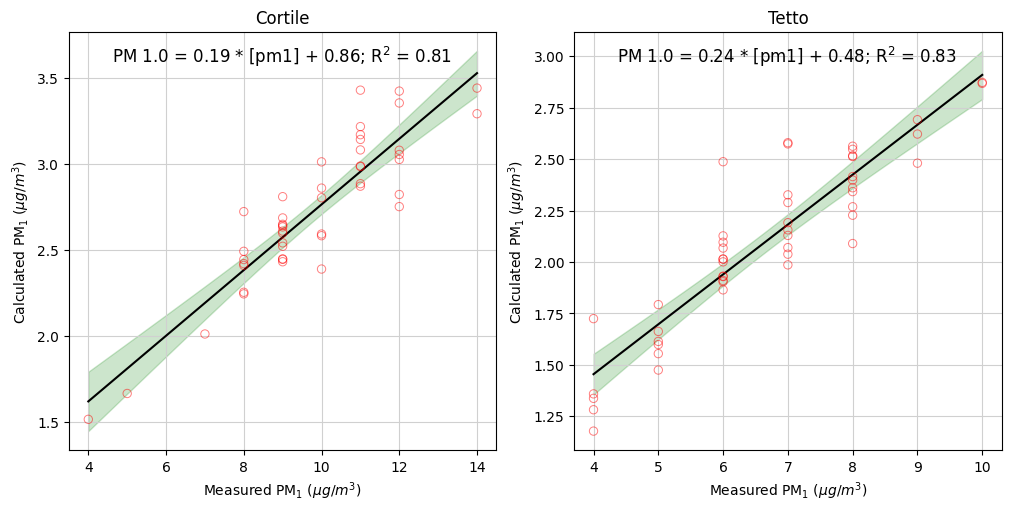

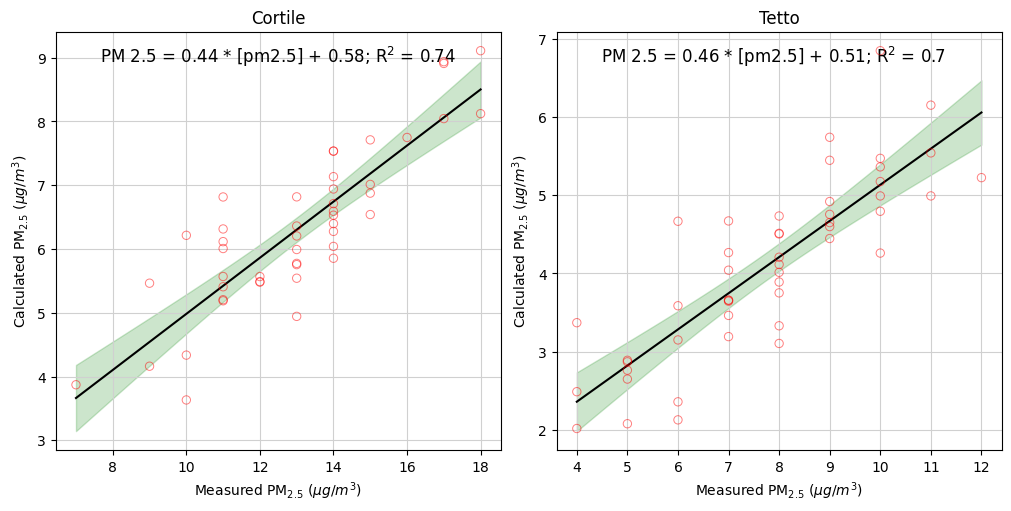

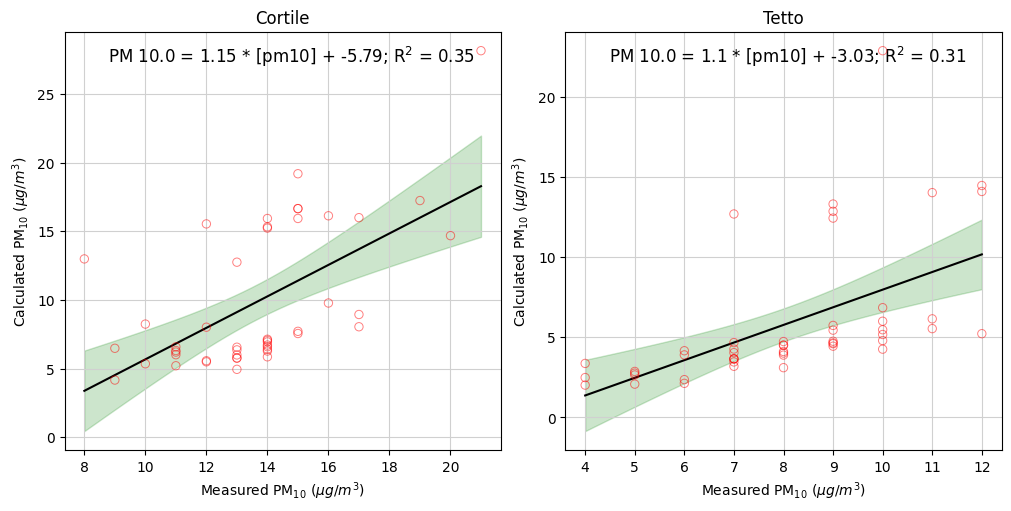

In [14]:
# If yout want to change the saving directory for your plots use the command:
# os.chdir('path of your directory for plots')

scatterPlot(cortile, tetto, 'PM 1.0', 'pm1', 'Measured PM$_1$ ($\\mu g/ m^3$)', 'Calculated PM$_1$ ($\\mu g/ m^3$)', 'img/PM1_plot.png', 'Cortile', 'Tetto')
scatterPlot(cortile, tetto, 'PM 2.5', 'pm2.5', 'Measured PM$_{2.5}$ ($\\mu g/ m^3$)', 'Calculated PM$_{2.5}$ ($\\mu g/ m^3$)', 'img/PM25_plot.png', 'Cortile', 'Tetto')
scatterPlot(cortile, tetto, 'PM 10.0', 'pm10', 'Measured PM$_{10}$ ($\\mu g/ m^3$)', 'Calculated PM$_{10}$ ($\\mu g/ m^3$)', 'img/PM10_plot.png', 'Cortile', 'Tetto')

Now we use the time series plots to compare the PM data. In this way we can evaluate if thw bias is constant, of if instead it changes in time. We also can note hoe the PM concentrations changed uring the experience.

We uset the timePlot() function, which is built here to give the same output as the homonymus function belonging to the R library openAir.

Note that these function save the plots in the same way scatterPlot does.

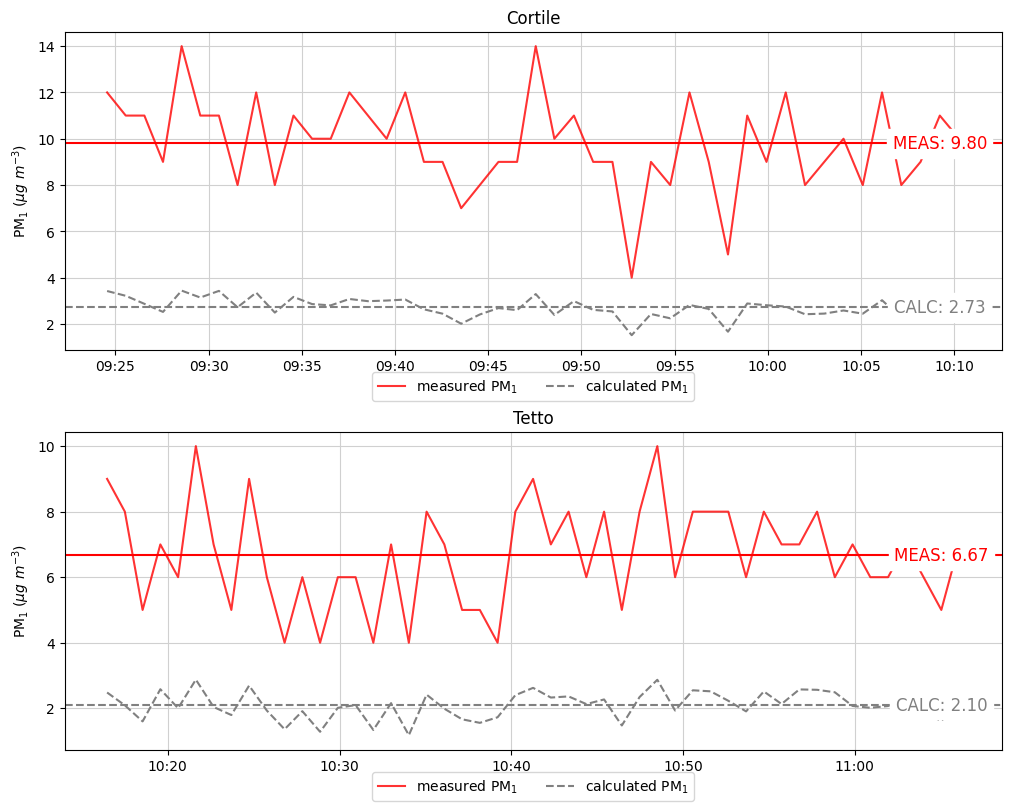

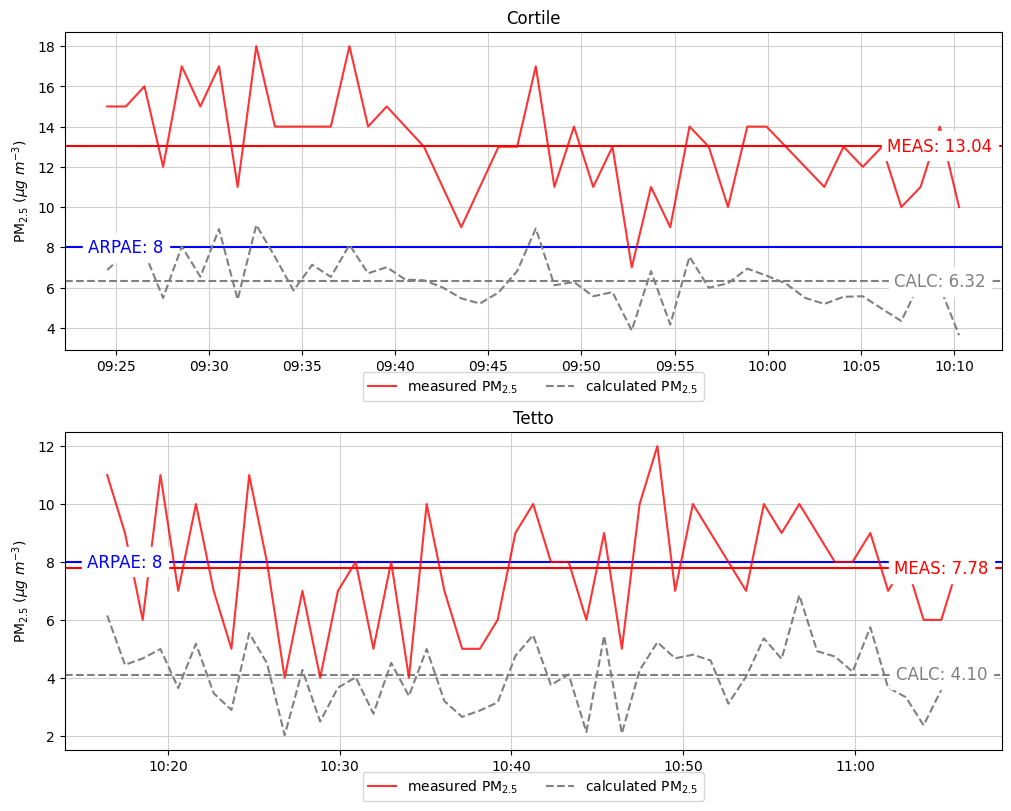

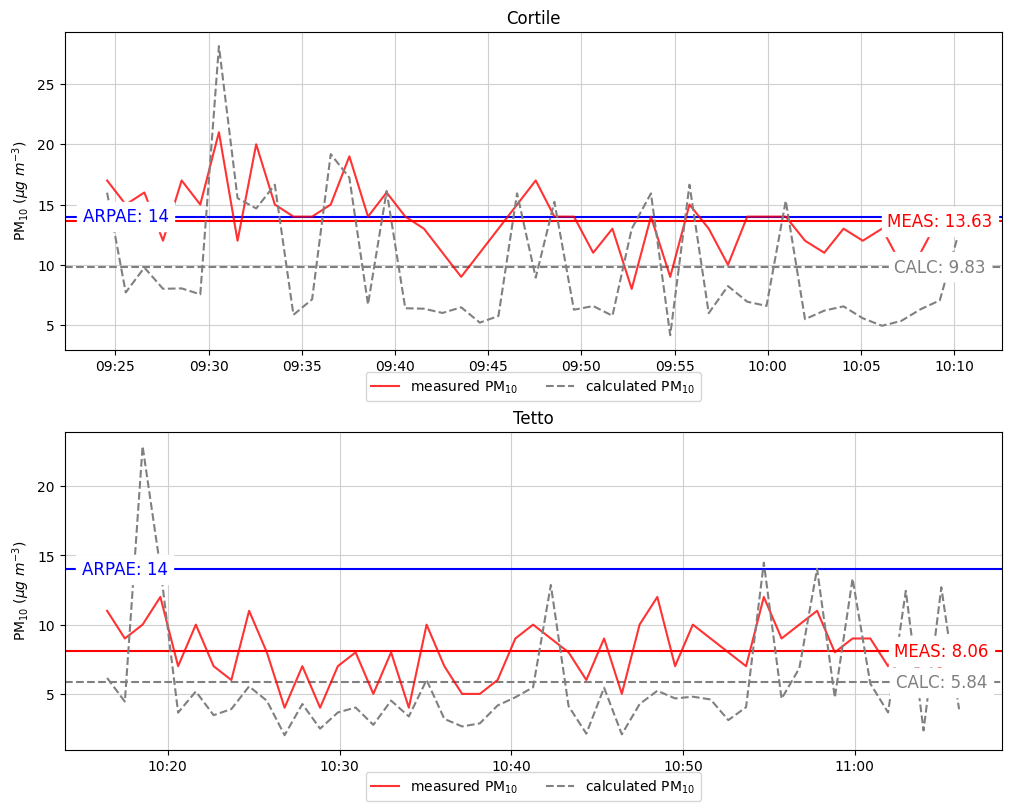

In [15]:
timePlot(cortile, tetto, 'Time', 'PM 1.0', 'measured PM$_{1}$', 'pm1', 'calculated PM$_{1}$', 'PM$_{1}$ ($\\mu g ~ m^{-3}$)', 'img/time_pm1.png', 'Cortile', 'Tetto', 0)
timePlot(cortile, tetto, 'Time', 'PM 2.5', 'measured PM$_{2.5}$', 'pm2.5', 'calculated PM$_{2.5}$', 'PM$_{2.5}$ ($\\mu g ~ m^{-3}$)', 'img/time_pm25.png', 'Cortile', 'Tetto', 8)
timePlot(cortile, tetto, 'Time', 'PM 10.0', 'measured PM$_{10}$', 'pm10', 'calculated PM$_{10}$', 'PM$_{10}$ ($\\mu g ~ m^{-3}$)', 'img/time_pm10.png', 'Cortile', 'Tetto', 14)

CALCOLO DIFFERENZE CALCOLATO E MISURATO DAL SENSORE

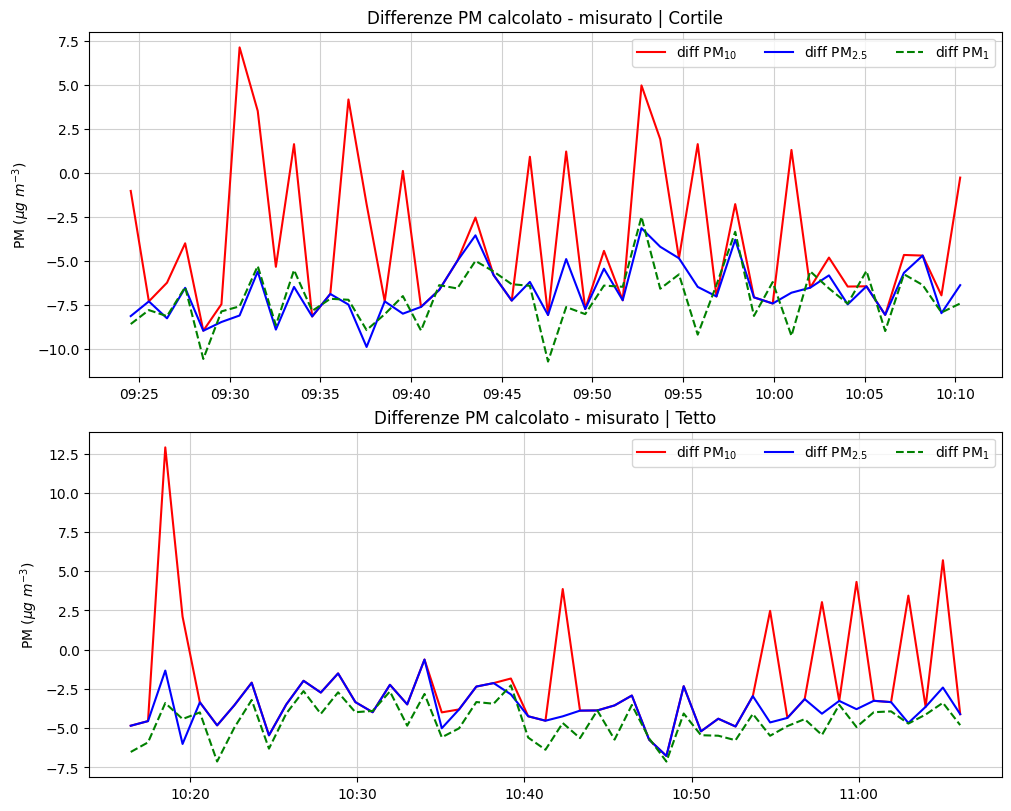

In [16]:
cortile['diff10'] = cortile['pm10'] - cortile['PM 10.0']
cortile['diff25'] = cortile['pm2.5'] - cortile['PM 2.5']
cortile['diff1'] = cortile['pm1'] - cortile['PM 1.0']

tetto['diff10'] = tetto['pm10'] - tetto['PM 10.0']
tetto['diff25'] = tetto['pm2.5'] - tetto['PM 2.5']
tetto['diff1'] = tetto['pm1'] - tetto['PM 1.0']

# figure and plot
fig,axes=plt.subplots(ncols=1, nrows=2,constrained_layout=True, figsize=(10,8))
ax = axes[0]
# background colors and grid 
#ax.set_facecolor("gainsboro")
ax.grid(color = "#d0d0d0")

# add timeseries of dataset fields in the plot
ax.plot(cortile['Time'],cortile['diff10'], 'r', alpha=1, zorder=5, label='diff PM$_{10}$')
ax.plot(cortile['Time'],cortile['diff25'], 'b', alpha=1, zorder=5, label='diff PM$_{2.5}$')
ax.plot(cortile['Time'],cortile['diff1'], 'g', linestyle="--",alpha=1, zorder=5, label='diff PM$_{1}$')
#  "#ff7f0e"
#  "#1f77b4"
#  "#2ca02c"
# formatting x axis to have 'hour:minute' format 
ax.xaxis.set_major_formatter(md.DateFormatter('%H:%M'))
ax.set_title("Differenze PM calcolato - misurato | Cortile")

# set limits to x and y axes (optional) 
#ax.set_xlim(left=0)
#ax.set_ylim(bottom=0)

# add name to x and y axes
#ax.set_xlabel(x_axis_name)
ax.set_ylabel('PM ($\\mu g ~ m^{-3}$)')

# add legend (you can change its position by modifying the loc attribute, i.e. 'lower right' or 'left' etc.)    
ax.legend(ncol=3, loc='upper right') #bbox_to_anchor=(0.5, -0.05))

##############################################################################################
ax = axes[1]
# background colors and grid 
#ax.set_facecolor("gainsboro")
ax.grid(color = "#d0d0d0")

# add timeseries of dataset fields in the plot
ax.plot(tetto['Time'],tetto['diff10'], 'r', alpha=1, zorder=5, label='diff PM$_{10}$')
ax.plot(tetto['Time'],tetto['diff25'], 'b', alpha=1, zorder=5, label='diff PM$_{2.5}$')
ax.plot(tetto['Time'],tetto['diff1'], 'g', linestyle='--', alpha=1, zorder=5, label='diff PM$_{1}$')

# formatting x axis to have 'hour:minute' format 
ax.xaxis.set_major_formatter(md.DateFormatter('%H:%M'))
ax.set_title("Differenze PM calcolato - misurato | Tetto")

# set limits to x and y axes (optional) 
#ax.set_xlim(left=0)
#ax.set_ylim(bottom=0)

# add name to x and y axes
#ax.set_xlabel(x_axis_name)
ax.set_ylabel('PM ($\\mu g ~ m^{-3}$)')

# add legend (you can change its position by modifying the loc attribute, i.e. 'lower right' or 'left' etc.)    
ax.legend(ncol=3, loc='upper right') #bbox_to_anchor=(0.5, -0.05))

# saving plot and closing figure (optional)
fig.savefig('img/diff_pm_cal-mis', bbox_inches='tight')
#plt.close(fig)

COMPARISON STATISTICS

We now also evaluate the comparison using appropriate statistical indicators. To calculate them, we use the modStats() function which calculates common numerical model evaluation statistics. This includes: 
- n, the number of complete pairs of data. 
- FAC2, fraction of predictions within a factor of two.
- MB, the mean bias. * MGE, the mean gross error. 
- NMB, the normalised mean bias. 
- NMGE, the normalised mean gross error. 
- RMSE, the root mean squared error. 
- r, the Pearson correlation coefficient. 
- COE, the Coefficient of Efficiency based on Legates and McCabe (1999, 2012). 
- IOA, the Index of Agreement based on Willmott et al. (2011), which spans between -1 and +1 with values approaching +1 representing better model performance. 
All statistics are based on complete pairs of mod (in our case, the calculated PM) and obs (in our case, the PM data retrieved directly by the sensor). 
NOTE: the list is rather complete, but you can consider to add the calculation of other parameters, using commands you used in other Experiences (e.g., Esperienza 3).

We now use again the pd.concat() function to merge the calculated statisitical parameters to a single dataframe. We then write the parameters for the three PM size fractions to a .txt file through the df.to_csv() function (df is the name of the dataframe). This function prints the dataframe to a file or connection. The arguments specify that we want to use the decimal point, the tab as separation, column names but not row names.

In [17]:
# computation of statistical values for each PMx
stat_pm1 = modStats(cortile, 'PM 1.0', 'pm1', 'PM_1')
stat_pm25 = modStats(cortile, 'PM 2.5', 'pm2.5', 'PM_2.5')
stat_pm10 = modStats(cortile, 'PM 10.0', 'pm10', 'PM_10')

# collecting all statistical values into a single dataframe
stat_PM = pd.concat((stat_pm1, stat_pm25, stat_pm10), axis = 1)

# save the dataframe as txt
stat_PM.to_csv('stat_PM_cortile.txt', sep=',')

Spearman r

We calculate also the Spearman correlation correlation coefficient. This coefficient is a non-parametric statistical measure of correlation, which measures the degree of correlation between two variables but without assuming that the relationship between them is linear. For this we first extract a single portion of data to be compared, and then use the stat.spearmanr() function to calculate the correlation. We finally use again the pd.concat() function to write the results to a .txt file in the working directory.

Comparison of particle distributions during different phases (locations) of the experience We now evaluate the difference in the particle distributions acquired by the sensor during the different phases (locations) of the experience. 

Firstly, we need to define the subsets for the different phases. We will do so by selecting the specific timesteps in the dataframe index, specifying directly the date and times of the different phases.

Here we select the part of dataset which belogns to a phase of the experiment. The selection can be done by asking to our
dataframe to select only the timesteps belonging to a specific range. This can be done in the following way (after setting
as index of our dataframe the timestep column):

    dataframe.loc['start_time':'end_time']

The ':' means for python to take into account every row in between the two extremes.

In the following example I asked to take all rows between 08:19 and 08:49 of the datos dataframe, and save it in the 
subdata1 variable. And accordingly I created a second phase variable for a different time range.

Remember to change date and time as appropriate.

In [18]:
cortile_mean = cortile.iloc[:, 1:].mean()
tetto_mean = tetto.iloc[:, 1:].mean()

# save the dataframe as txt
#cortile_mean.to_csv('cortile average.txt', sep=',')
#tetto_mean.to_csv('tetto average.txt', sep=',')
print(cortile_mean)
print(tetto_mean)

Temperature              20.281957
Humidity                 67.462609
Battery                  98.000000
Light                   515.500000
Noise dBA                51.293261
Barometric pressure     100.945000
VOC Gas CCS811            8.065217
eCO2 Gas CCS811         455.869565
PM 1.0                    9.804348
PM 2.5                   13.043478
PM 10.0                  13.630435
PN 0.3                 1520.934783
PN 0.5                  452.521739
PN 1.0                   65.586957
PN 2.5                    1.717391
PN 5.0                    0.652174
PN 10.0                   0.347826
pm1                       2.726097
pm2.5                     6.320660
pm10                      9.831142
diff10                   -3.799293
diff25                   -6.722818
diff1                    -7.078251
dtype: float64
Temperature              25.763061
Humidity                 52.638776
Battery                  97.367347
Light                  5302.836735
Noise dBA                54.622857
Barom

We extract particle number data from the two subsets. Here we convert the particle counts into particle numerical concentration, so the unit changes from # to #/cm3.

In [19]:
PN_cortile = cortile_mean.loc['PN 0.3':'PN 10.0']*10**(-2)
PN_tetto = tetto_mean.loc['PN 0.3':'PN 10.0']*10**(-2)
PN_cortile, PN_tetto

(PN 0.3     15.209348
 PN 0.5      4.525217
 PN 1.0      0.655870
 PN 2.5      0.017174
 PN 5.0      0.006522
 PN 10.0     0.003478
 dtype: float64,
 PN 0.3     11.764286
 PN 0.5      3.485714
 PN 1.0      0.365306
 PN 2.5      0.004898
 PN 5.0      0.003673
 PN 10.0     0.002857
 dtype: float64)

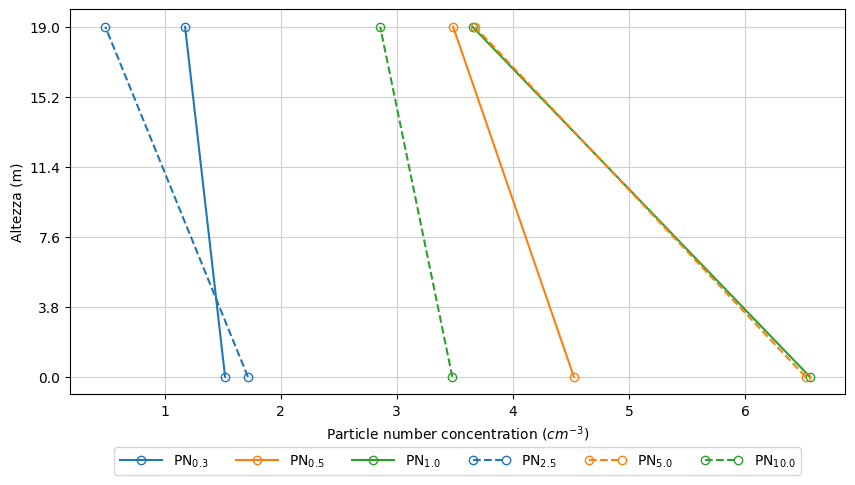

In [ ]:
from matplotlib.legend_handler import HandlerLine2D
# figure and plot
fig, ax = plt.subplots(ncols=1, nrows=1,figsize=(10,5))
ax.set_title('')
# background colors and grid 
#ax.set_facecolor("gainsboro")
ax.grid(color = "#d0d0d0")
# add name to x and y axes
ax.set_ylabel('Altezza (m)') 
ax.set_xlabel('Particle number concentration ($cm^{-3}$)')

#ax.set_xscale('log')
y = [0, 19]
ax.set_yticks(np.linspace(0,19.0,6))#, labels=["cortile", "tetto"])
#  "#ff7f0e"
#  "#1f77b4"
#  "#2ca02c"
ax.plot([PN_cortile['PN 0.3']/10,PN_tetto['PN 0.3']/10], y, label = "PN$_{0.3}$", marker = 'o', mfc='none')
ax.plot([PN_cortile['PN 0.5']/1,PN_tetto['PN 0.5']/1], y, label = "PN$_{0.5}$", marker = 'o', mfc='none')
ax.plot([PN_cortile['PN 1.0']/0.1,PN_tetto['PN 1.0']/0.1], y, label = "PN$_{1.0}$", marker = 'o', mfc='none')
line3, = ax.plot([PN_cortile['PN 2.5']/0.01,PN_tetto['PN 2.5']/0.01], y, label = "PN$_{2.5}$", color="#1f77b4", linestyle = "--", marker = 'o', mfc='none')
line4, = ax.plot([PN_cortile['PN 5.0']/0.001,PN_tetto['PN 5.0']/0.001], y, label = "PN$_{5.0}$", color="#ff7f0e", linestyle = "--", marker = 'o', mfc='none')
line5, = ax.plot([PN_cortile['PN 10.0']/0.001,PN_tetto['PN 10.0']/0.001], y, label = "PN$_{10.0}$", color="#2ca02c", linestyle = "--", marker = 'o', mfc='none')

ax.legend(ncol=6, loc='upper center', bbox_to_anchor=(0.5, -0.12), handler_map={line3: HandlerLine2D(numpoints=2), line4: HandlerLine2D(numpoints=2), line5: HandlerLine2D(numpoints=2)}, handlelength=3)

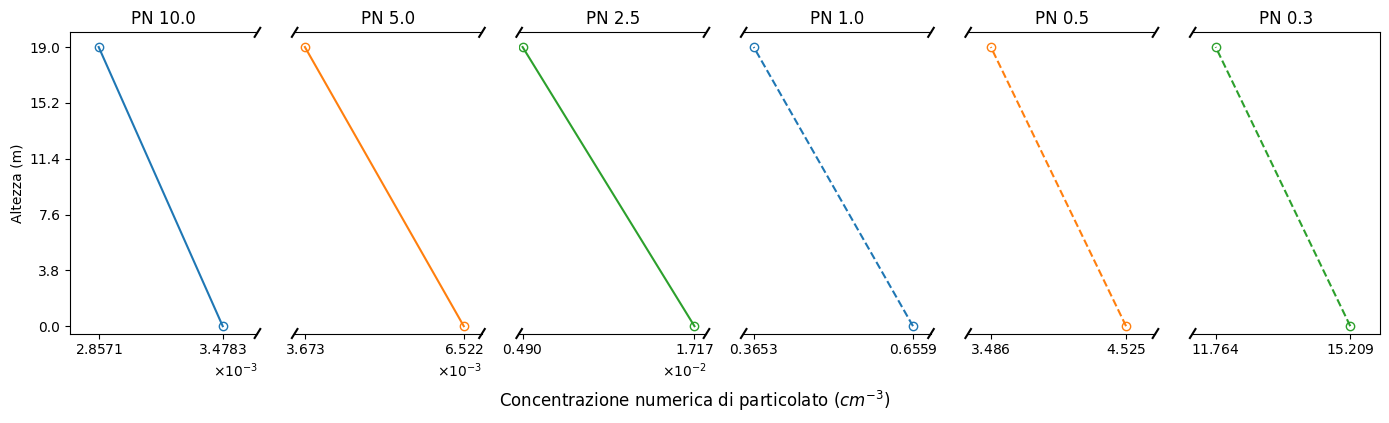

In [153]:
from matplotlib.ticker import ScalarFormatter

PNN_cortile = PN_cortile[::-1].copy()
PNN_tetto = PN_tetto[::-1].copy()

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Definisco i 6 intervalli x da mostrare
x_intervals = []
for i in range(6):
    minn = min(PNN_cortile.iloc[i],PNN_tetto.iloc[i])
    maxx = max(PNN_cortile.iloc[i],PNN_tetto.iloc[i])
    x_intervals.append((minn-minn/20, maxx+maxx/20))

fig, axs = plt.subplots(1, 6, figsize=(14, 4), sharey=True)
plt.subplots_adjust(wspace=-0.05) # adjust space between Axes
y = [0, 19]

for i, (x_min, x_max) in enumerate(x_intervals):
    ax = axs[i]

    if i < 3:
        ax.plot([PNN_cortile.iloc[i],PNN_tetto.iloc[i]], y, marker = 'o', mfc='none', color=colors[i % 3])# label = "PN$_{0.3}$")
    else:
        ax.plot([PNN_cortile.iloc[i],PNN_tetto.iloc[i]], y, marker = 'o', mfc='none', color=colors[i % 3], linestyle="--")# label = "PN$_{0.3}$")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.5, 20)
    ax.set_xticks([PNN_cortile.iloc[i],PNN_tetto.iloc[i]])#, labels=["cortile", "tetto"])
    ax.set_title(PNN_cortile.index[i])

    ##not scient
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))  # forzerà la notazione scientifica per valori grandi o piccoli
    ax.xaxis.set_major_formatter(formatter)

    if i ==0 :
        ax.set_ylabel('Altezza (m)')
    # Solo il primo plot mostra label y
    if i != 0:
        #ax.set_yticklabels([])
        ax.set_yticks(np.linspace(0,19.0,6))#, labels=["cortile", "tetto"])
        ax.tick_params(axis='y', which='both', length=0)

    # Rimuovo i bordi sinistro per tutti tranne il primo
    if i > 0:
        ax.spines['left'].set_visible(False)

    # Rimuovo i bordi destro per tutti tranne l'ultimo
    if i < 5:
        ax.spines['right'].set_visible(False)

    # Aggiungo lineette diagonali agli estremi della rottura
    d = .015  # dimensione lineetta

    # Lineette lato destro, tranne ultimo plot
    if i < 5:
        kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
        ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)          # diagonale in basso
        ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)    # diagonale in alto

    # Lineette lato sinistro, tranne primo plot
    if i > 0:
        kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
        ax.plot((-d, +d), (-d, +d), **kwargs)                # diagonale in basso
        ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)          # diagonale in alto

    # Etichette X
    #ax.set_xlabel(f'{x_min} - {x_max}')

#fig.suptitle('Grafico con asse X spezzato in 6 intervalli')
fig.text(0.5, -0.03, 'Concentrazione numerica di particolato ($cm^{-3}$)', ha='center', fontsize=12)
plt.tight_layout()
fig.savefig('img/verticale.png', bbox_inches='tight', dpi=300)


We now plot the average particle size distributions in the two phases to compare them. To do so, we want to plot the two (or more, if needed) distributions on the same graph. We first plot the distribution for the first phase, using a log scale for both x and y axes. Then we add the plot for the second phase on the same graph. We then add the tick labels (need to be modified), and finally add the legend. 

Since the y-axis range of the plots are not necessarily the same, we also specify the same ranges for all the plots. Note: as done above, the plots will be produced directly on the right screen of the IDE program (Spyder or VSC) and you can save it through the Export command. If you wish to directly save it on a png file, add the appropriate commands.

PARTICLE NUMBER DISTRIBUTION

In [ ]:
D_opc

array([ 0.40816551,  0.77680813,  1.85118016,  3.88404063,  7.76808126,
       12.66449255])

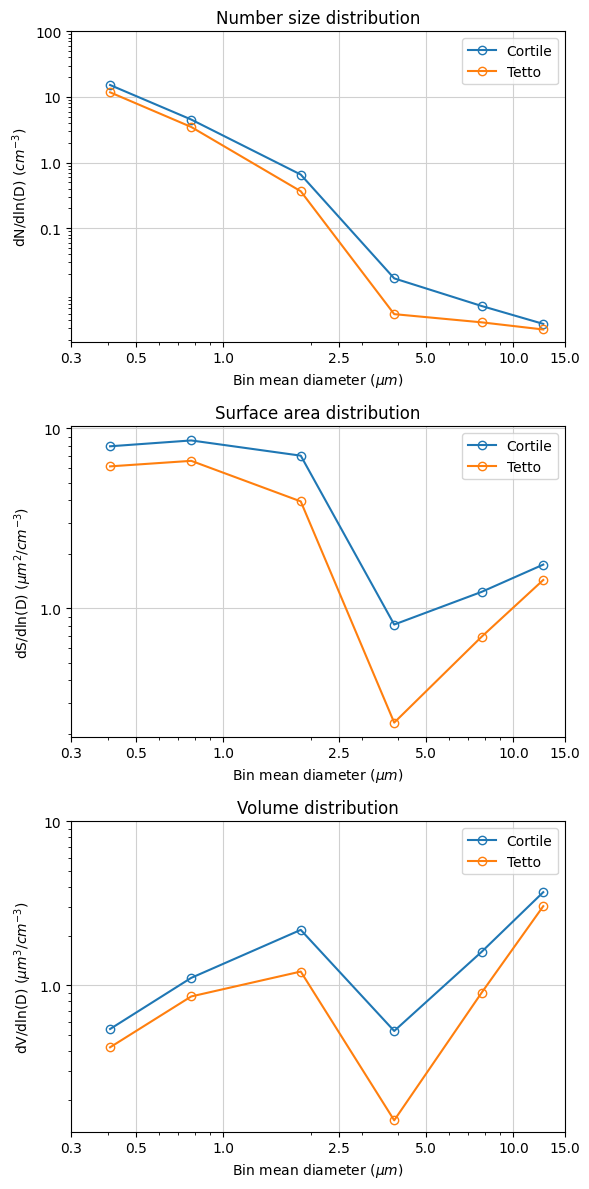

In [ ]:
# figure and plot
fig, axes = plt.subplots(ncols=1, nrows=3,figsize=(6,12))
ax = axes[0]
ax.set_title('Number size distribution')
# background colors and grid 
#ax.set_facecolor("gainsboro")
ax.grid(color = "#d0d0d0")

# add distributon of dataset fields in the plot
ax.plot(D_opc, PN_cortile, marker = 'o', mfc='none', label='Cortile')
ax.plot(D_opc, PN_tetto, marker = 'o', mfc='none', label='Tetto')

# set a logaritmic scale on the x and y axes
ax.set_yscale('log')
ax.set_xscale('log') 

# set y axis limits
#ax.set_ylim(0.01, 200)

# set x and y axes thicks
ax.set_xticks([0.3, 0.5, 1.0, 2.5, 5.0, 10.0, 15.0], labels=[0.3, 0.5, 1.0, 2.5, 5.0, 10.0, 15.0])
ax.set_yticks([0.1, 1.0, 10, 100], labels=[0.1, 1.0, 10, 100])

# add name to x and y axes
ax.set_xlabel('Bin mean diameter ($\\mu m$)') 
ax.set_ylabel('dN/dln(D) ($cm^{-3}$)')

# add legend
ax.legend(loc = "upper right") 
#######################################################################################
ax = axes[1]
ax.set_title('Surface area distribution')
# computing surfaces under spherical particle hypothesis 
S_opc = np.pi * D_opc**2

# particle surface distribution for each stage of the experiment
PS_tetto = S_opc * PN_tetto
PS_cortile = S_opc * PN_cortile

# background colors and grid 
#ax.set_facecolor("gainsboro")
ax.grid(color = "#d0d0d0")

# add distribution of dataset fields in the plot
ax.plot(D_opc, PS_cortile, marker = 'o', mfc='none', label='Cortile')
ax.plot(D_opc, PS_tetto, marker = 'o', mfc='none', label='Tetto')

# set a logaritmic scale on the x and y axes
ax.set_yscale('log')
ax.set_xscale('log')

# set y axis limits
#ax.set_ylim(1, 100)

# set x and y axes thicks
ax.set_xticks([0.3, 0.5, 1.0, 2.5, 5.0, 10.0, 15.0], labels=[0.3, 0.5, 1.0, 2.5, 5.0, 10.0, 15.0])
ax.set_yticks([1.0, 10], labels=[1.0, 10])

# add name to x and y axes
ax.set_xlabel('Bin mean diameter ($\\mu m$)') 
ax.set_ylabel('dS/dln(D) ($ \\mu m^2 /  cm^{-3}$)')

# add legend
ax.legend(loc = "upper right") 
###############################################################################################
ax = axes[2]
ax.set_title("Volume distribution")
# computing volumes under spherical particle hypothesis 
V_opc = np.pi/6 * D_opc**3

# particle volume distribution for each stage of the experiment
PV_cortile = PN_cortile * V_opc
PV_tetto = PN_tetto * V_opc 

# background colors and grid 
#ax.set_facecolor("gainsboro")
ax.grid(color = "#d0d0d0")

# add distribution of dataset fields in the plot
ax.plot(D_opc, PV_cortile, marker = 'o', mfc='none', label='Cortile')
ax.plot(D_opc, PV_tetto, marker = 'o', mfc='none', label='Tetto')

# set a logaritmic scale on the x and y axes
ax.set_yscale('log')
ax.set_xscale('log') 

# set y axis limits
#ax.set_ylim(1, 100)

# set x and y axes thicks
ax.set_xticks([0.3, 0.5, 1.0, 2.5, 5.0, 10.0, 15.0], labels=[0.3, 0.5, 1.0, 2.5, 5.0, 10.0, 15.0])
ax.set_yticks([1.0, 10], labels=[1.0, 10])

# add name to x and y axes
ax.set_xlabel('Bin mean diameter ($\\mu m$)') 
ax.set_ylabel('dV/dln(D) ($ \\mu m^3 /  cm^{-3}$)')

# add legend
ax.legend(loc = "upper right") 
#########################################################################################

# optional function to better manage spaces in the plot
plt.tight_layout() 

# saving plot and closing figure (optional)
fig.savefig('img/part_distr.png', bbox_inches='tight', dpi=300)
#plt.close(fig)

We can also calculate the mean and standard deviation using the mean and sd functions. Here they are calculated for particle counts in the 0.3 micron size bin, but if you need you can change this as appropriate.

Calculate summary statistics to compare the two phases. Repeat if necessary.


Note: the summary function also saves the dataset as a txt table.

Visualization of the data distribution for the 2 locations

First, we will plot the counts with histograms. Then, we will plot the normal distribution, which mimics t-distribution when sample number (N) is large.
To visualize the normal distribution, we should know: 
- The sample mean; 
- Sample standard deviation; 

We can also use the function ‘stats.gaussian_kde(x)’ to plot the probability density against x, and the PM values in different locations. Then, visually, we can see in one figure that difference between the 2 places, how much is the difference between their mean PM values and what is the extent of # deviation of the PM (particle counts) measurements in each location. Firstly we define the bin width for the histogram. We then calculate the sum of the rows corresponding to the particle counts in the two phases. And then we calculate the means and standard deviation of those sums in the two periods (locations).

In [ ]:
# sum number concentration for each timestep in the two steps of the experiment
sum_cortile = cortile.loc[:,'PN 0.3':'PN 10.0'].sum(axis=1)
sum_tetto = tetto.loc[:,'PN 0.3':'PN 10.0'].sum(axis=1) ## numero totale particelle per ogni minuti, singola misura
print(len(sum_cortile))
print(len(sum_tetto))

# compute the means of the two phases of the experiment
cortile_mu = sum_cortile.mean()
tetto_mu = sum_tetto.mean()

# compute the standard deviation of the two phases of the experiment
cortile_sd = np.std(sum_cortile, ddof=1) # divide per N-1
tetto_sd = np.std(sum_tetto, ddof=1)

46
49


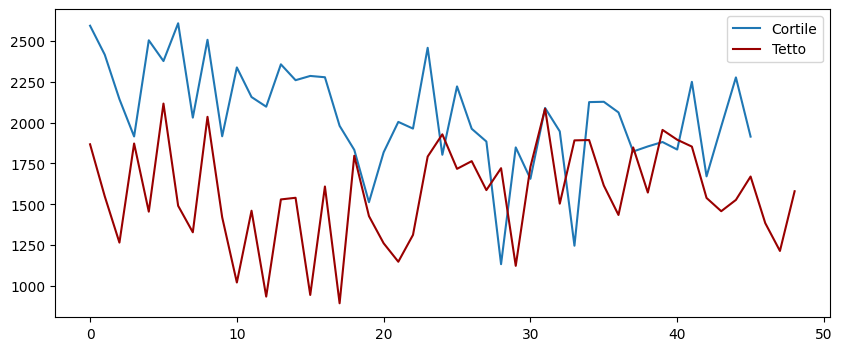

In [ ]:
fig, axes = plt.subplots(ncols=1, nrows=1,figsize=(10,4))
plt.plot(cortile.index, sum_cortile, label='Cortile')
plt.plot(tetto.index, sum_tetto, color=(153/255,0,0), label='Tetto')
plt.legend(loc = "upper right")

Let’s make the plot. First we call the function and then each function is dedicated to a specific graphic command.

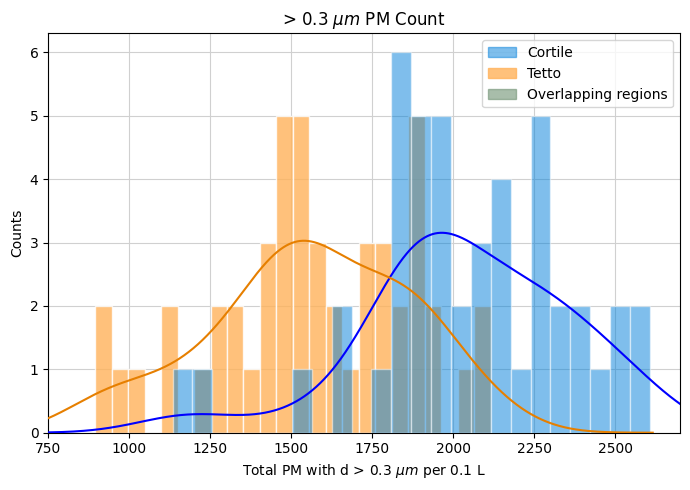

In [ ]:
# figure and plot
fig, ax = plt.subplots(tight_layout=True,figsize=(7,5))

# background colors and grid 
#ax.set_facecolor("gainsboro")
ax.grid(color = "#d0d0d0")

# histograms, bins can be either automatically determined or passed to the function with the bins attribute
ax.hist(sum_tetto, bins=np.linspace(sum_tetto.min(), sum_tetto.max(), 25), color="#ffb25a", edgecolor='white', alpha = 0.8, zorder=2)
ax.hist(sum_cortile, bins=np.linspace(sum_cortile.min(), sum_cortile.max(), 25), color="#007fda", edgecolor='white', alpha = 0.5, zorder=3)

# compute probability density functions
density_cortile = stats.gaussian_kde(sum_cortile)
density_tetto = stats.gaussian_kde(sum_tetto)

x_cortile = np.arange(sum_cortile.min()-500, sum_cortile.max()+500, 0.1)
x_tetto = np.arange(sum_tetto.min()-500, sum_tetto.max()+500, 0.1)

ax.plot(x_cortile, 2500*density_cortile(x_cortile), zorder=4, color = 'b') # Multiplied by 2500 for visualisation only
ax.plot(x_tetto, 2500*density_tetto(x_tetto), zorder=5, color = "#e67f00") # Multiplied by 2500 for visualisation only

# add name to x and y axes
ax.set_xlabel('Total PM with d > 0.3 $\\mu m$ per 0.1 L')
ax.set_ylabel('Counts')
ax.set_xlim(750,2700)

# add title to the plot
ax.set_title('> 0.3 $\\mu  m$ PM Count')

# add legend
s1 = mpatches.Patch(color="#007fda", alpha = 0.5, label='Cortile')
s2 = mpatches.Patch(color="#ffb25a", alpha = 0.8, label='Tetto')
s3 = mpatches.Patch(color="#6F9172", alpha = 0.6, label='Overlapping regions')
ax.legend(handles=[s1, s2, s3])

# optional function to better manage spaces in the plot
plt.tight_layout()

# saving plot and closing figure (optional)
fig.savefig("img/count_distrib.png", dpi=300, bbox_inches='tight')
#plt.close(fig)


We then plot the normal distribution. To do so, we make use of the stats.norm.pdf() function. First we need to calculate the data that then will be visualized. To do so, we make use of the stats.norm.pdf() function and of the observed mean and standard deviation for the two locations.

In [ ]:
# computing the normal distribution given mean and standard deviation of the first dataset
x1norm = np.linspace(cortile_mu - cortile_mu/2, cortile_mu + cortile_mu/2, 1001)
y1norm = stats.norm.pdf(x1norm, loc = cortile_mu, scale = cortile_sd)
first_ydnorm = pd.DataFrame({'x1' : x1norm, 'y1_norm' : y1norm})

# computing the normal distribution given mean and standard deviation of the second dataset
x2norm = np.linspace(tetto_mu - tetto_mu/2, tetto_mu + tetto_mu/2, 1001)
y2norm = stats.norm.pdf(x2norm, loc = tetto_mu, scale = tetto_sd)
second_ydnorm = pd.DataFrame({'x2' : x2norm, 'y2_norm' : y2norm})

We can now produce the plot. First we reset the bin width and then we plot the normally distributed data that we just obtained.

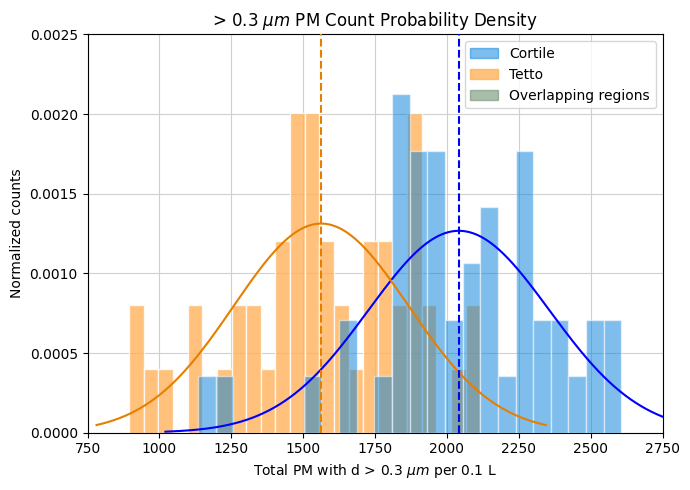

In [ ]:
# figure and plot
fig, ax = plt.subplots(tight_layout=True,figsize=(7,5))

# background colors and grid 
#ax.set_facecolor("gainsboro")
ax.grid(color = "#d0d0d0")

# histograms, bins can be either automatically determined or passed to the function with the bins attribute
# since the attribute density is set true counts are normalized over the total occurrences
ax.hist(sum_tetto, bins=np.linspace(sum_tetto.min(), sum_tetto.max(), 25), color="#ffb25a", density = True, edgecolor='white', alpha = 0.8, zorder=2)
ax.hist(sum_cortile, bins=np.linspace(sum_cortile.min(), sum_cortile.max(), 25), color="#007fda", density = True, edgecolor='white', alpha = 0.5, zorder=3)

# normal probability density functions plots
ax.plot(first_ydnorm.x1, first_ydnorm.y1_norm, zorder=4, color = 'b')
ax.plot(second_ydnorm.x2, second_ydnorm.y2_norm, zorder=5, color = "#e67f00")

# vertical lines representing the mean of each dataset
ax.plot([cortile_mu, cortile_mu], [0, 1], linestyle = '--', color='blue', zorder = 6)
ax.plot([tetto_mu, tetto_mu], [0, 1], linestyle = '--', color = "#e67f00", zorder = 6)

# set y axis limits
ax.set_ylim([0, 0.0025])
ax.set_xlim(750,2750)

# add name to x and y axes
ax.set_xlabel('Total PM with d > 0.3 $\\mu m$ per 0.1 L')
ax.set_ylabel('Normalized counts')

# add title to the plot
ax.set_title('> 0.3 $\\mu  m$ PM Count Probability Density')

# add legend
s1 = mpatches.Patch(color="#007fda", alpha = 0.5, label='Cortile')
s2 = mpatches.Patch(color="#ffb25a", alpha = 0.8, label='Tetto')
s3 = mpatches.Patch(color="#6F9172", alpha = 0.6, label='Overlapping regions')
ax.legend(handles=[s1, s2, s3])

# optional function to better manage spaces in the plot
plt.tight_layout() 

# saving plot and closing figure (optional)
fig.savefig("img/count_distrib_norm.png", dpi=300, bbox_inches='tight')
#plt.close(fig)

t-test

In this section, we are going to perform hypothesis test on the PM data we obtain in different locations (say, courtyard & bus stop), to test if the PM data in courtyard is either significantly greater, less, or different from the PM data at the bus stop. We are going to use t-test, a statistical inference tool to do our hypothesis test. Because we are interested to know if the mean values of the courtyard are significantly different than those at the bus stop, we set the alternative hypothesis to ask whether the mean for Place 1 (courtyard) is different than for Place 2 (bus stop). The confidence level is set at 0.95.

In [ ]:
'''
Computing all statistical values for the t-test. With cl you can set the confidence level, eq-var set false means that the two 
sets of data have different variance. This function provides a two-sided t-test.
'''
t_test_PM = ttest(sum_cortile, sum_tetto, cl = 0.95, eq_var = True)

# save the dataframe as txt
#t_test_PM.to_csv('ttest_results.txt', sep=',')

Welch Two Sample t-test
t = 7.545455866381222
df = 93.0
p-value = 2.983544100876972e-11

95.0 percent confidence interval:
lower bound = 352.86032
upper bound = 605.31448

sample estimates (mean, std, n):
x1: (2041.761, 314.843, 46.0)
x2: (1562.673, 303.962, 49.0)


Visualization of the t-test results

Here we plot our t-distributions for our t-tests, inputs are:
- T Probability Density = t.pdf(x, df), where x is a vector of t-values (we can imagine that t-value is the normalized mean value of our data) where df is the Degree of Freedom (df=t_test_PM.loc['df']), which has been calculated using the ttest() function 
- Critical t-value for the t-test, which defines as crit_val = t.ppf(.95, df=t_test_PM.loc['df']) 
- t-value, defined as t_test_PM.loc['t'] which has been calculated in our t-test as well. 

Similar as what we do above, to perform our t-test visually, we want to compare the t-value and critical t-value – if |t-value| is greater than |critical t-value|, we reject the null hypothesis.

First we calculate the values and the intervals.

In [ ]:
# creating a vector of x data
x_t = pd.DataFrame(np.linspace(-6, 6, 1000), columns=['x']) # replaced len(subset1) with 1000 tp have a smoother t-test chart

# calculating the probability density function using the x vector
y_t = pd.DataFrame(t.pdf(x_t, df=t_test_PM.loc['df']), columns=['y'])

# creating a dataset for x and y of the probability density function
t_test = pd.concat([x_t, y_t], axis=1)

# computing the critical values for the t-test, note that it is two-sided so we have to consider higher and lower parts of the distribution
crit_val_hi = t.ppf(0.975, df=t_test_PM.loc['df'])
crit_val_lo = t.ppf(0.025, df=t_test_PM.loc['df'])

In [ ]:
# creating a dataframe to compute the shaded area in the higher part of distribution
shade1 = pd.concat([pd.DataFrame({'x' : [crit_val_hi.item()], 'y' : [0]}),
                    t_test.loc[t_test.x > crit_val_hi.item()],
                    pd.DataFrame({'x' : [np.inf], 'y' : [0]})], ignore_index=True)

# creating a dataframe to compute the shaded area in the lower part of distribution
shade2 = pd.concat([pd.DataFrame({'x' : [-np.inf], 'y' : [0]}),
                    t_test.loc[t_test.x < crit_val_lo.item()],
                    pd.DataFrame({'x' : [crit_val_lo.item()], 'y' : [0]})], ignore_index=True)

We then plot the results again by using matplotlib library and a series of graphic commands to make the plot nice.

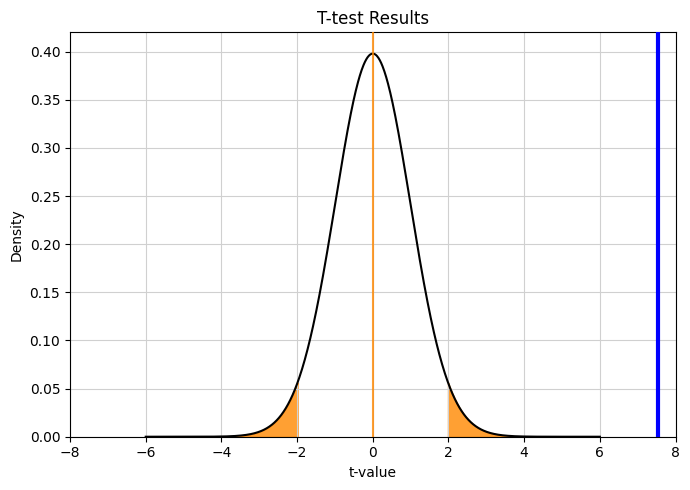

In [ ]:
# figure and plot
fig, ax = plt.subplots(tight_layout=True,figsize=(7,5))

# background colors and grid 
#ax.set_facecolor("gainsboro")
ax.grid(color = "#d0d0d0")

# create the t distribution plot
ax.plot(t_test.x, t_test.y, zorder=4, color = 'k')

# fill the shaded areas defined by the higher and lower critical values of t-test
ax.fill_between(shade1.x, np.zeros(len(shade1)), shade1.y, color="#ff8800", alpha = 0.8)
ax.fill_between(shade2.x, np.zeros(len(shade2)), shade2.y, color="#ff8800", alpha = 0.8)

# creating the vertical line representing the 0
ax.plot([0, 0], [0, 0.5], color="#ff8800", alpha= 0.8, zorder = 6)

# add vertical line representing the t-test critical value found
ax.plot([t_test_PM.loc['t'], t_test_PM.loc['t']], [0, 0.5], color='b', linewidth = 3, zorder = 6)

# add title to the plot
ax.set_title('T-test Results')

# add name to x and y axes
ax.set_xlabel('t-value')
ax.set_ylabel('Density')

# set x and y axes limits
ax.set_ylim([0, 0.42])
ax.set_xlim([-8, 8])

# optional function to better manage spaces in the plot
plt.tight_layout()

# saving plot and closing figure (optional)
#fig.savefig(saving_name, bbox_inches='tight')
fig.savefig("img/ttest_result.png", dpi=300, bbox_inches='tight')
#plt.close(fig)

T TEST PER CLASSI PM


In [ ]:
t_test_PM = ttest(cortile['PN 0.3'], tetto['PN 0.3'], cl = 0.95, eq_var = True)

Welch Two Sample t-test
t = 7.202151160888332
df = 93.0
p-value = 1.5154181391400656e-10

95.0 percent confidence interval:
lower bound = 249.38308
upper bound = 439.62935

sample estimates (mean, std, n):
x1: (1520.935, 238.283, 46.0)
x2: (1176.429, 227.929, 49.0)


In [ ]:
t_test_PM = ttest(cortile['PN 0.5'], tetto['PN 0.5'], cl = 0.95, eq_var = True)

Welch Two Sample t-test
t = 7.249576509942095
df = 93.0
p-value = 1.2119655599204956e-10

95.0 percent confidence interval:
lower bound = 75.47791
upper bound = 132.42271

sample estimates (mean, std, n):
x1: (452.522, 69.779, 46.0)
x2: (348.571, 69.905, 49.0)


In [ ]:
t_test_PM = ttest(cortile['PN 1.0'], tetto['PN 1.0'], cl = 0.95, eq_var = True)

Welch Two Sample t-test
t = 8.256251220260559
df = 93.0
p-value = 9.85450237383428e-13

95.0 percent confidence interval:
lower bound = 22.0334
upper bound = 36.07929

sample estimates (mean, std, n):
x1: (65.587, 18.455, 46.0)
x2: (36.531, 15.813, 49.0)


In [ ]:
t_test_PM = ttest(cortile['PN 2.5'], tetto['PN 2.5'], cl = 0.95, eq_var = True)

Welch Two Sample t-test
t = 3.3770673575856605
df = 93.0
p-value = 0.001071027108973837

95.0 percent confidence interval:
lower bound = 0.48912
upper bound = 1.96607

sample estimates (mean, std, n):
x1: (1.717, 2.344, 46.0)
x2: (0.49, 0.96, 49.0)


In [ ]:
t_test_PM = ttest(cortile['PN 5.0'], tetto['PN 5.0'], cl = 0.95, eq_var = True)

Welch Two Sample t-test
t = 1.444232346818338
df = 93.0
p-value = 0.15203423630887386

95.0 percent confidence interval:
lower bound = -0.10882
upper bound = 0.67847

sample estimates (mean, std, n):
x1: (0.652, 1.037, 46.0)
x2: (0.367, 0.883, 49.0)


In [ ]:
t_test_PM = ttest(cortile['PN 10.0'], tetto['PN 10.0'], cl = 0.95, eq_var = True)

Welch Two Sample t-test
t = 0.3816761608082477
df = 93.0
p-value = 0.7035722608207254

95.0 percent confidence interval:
lower bound = -0.26322
upper bound = 0.38744

sample estimates (mean, std, n):
x1: (0.348, 0.875, 46.0)
x2: (0.286, 0.707, 49.0)


Calculate the moments

As a final and optional point, we will calculate the moments of the particle size distributions for the phases of the experience. We have two options: either we apply the direct calculation (maybe defining a function), either we make use of the formulae given on the right of slide 89. Let’s use the formulae given on the right.

In [ ]:
# moment of order zero is just the total number of particles (convert back to # particles)
totPN1 = PN1.sum() * 10
totPN2 = PN2.sum() * 10

# moment of order one is the average particle diameter multiplied the moment of order zero
mean_diam = D_opc.mean()
mom1_1 = totPN1 * mean_diam
mom1_2 = totPN2 * mean_diam

# moment of order two is the average surface area multiplied the moment of order zero and divided by pi
mean_area = np.pi * mean_diam**2
mom2_1 = mean_area * totPN1 / np.pi
mom2_2 = mean_area * totPN2 / np.pi

# moment of order three is the average volume multiplied six times the moment of order zero and divided by pi
mean_vol = np.pi/6*mean_diam**3
mom3_1 = mean_vol * 6 * totPN1/np.pi
mom3_2 = mean_vol * 6 * totPN2/np.pi